## Exploratory Data Analysis

### Roles to Explore:

In [2]:
# importing libraries
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns 

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# # data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for India Data Analyst Roles

In [3]:
df_DA_IN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

### Job Locations to Explore:

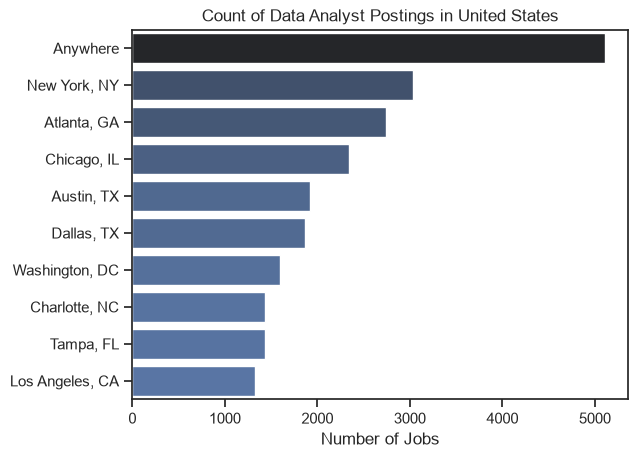

In [4]:
df_plot = df_DA_IN['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
plt.title('Count of Data Analyst Postings in United States')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()


### Job Opportunities:

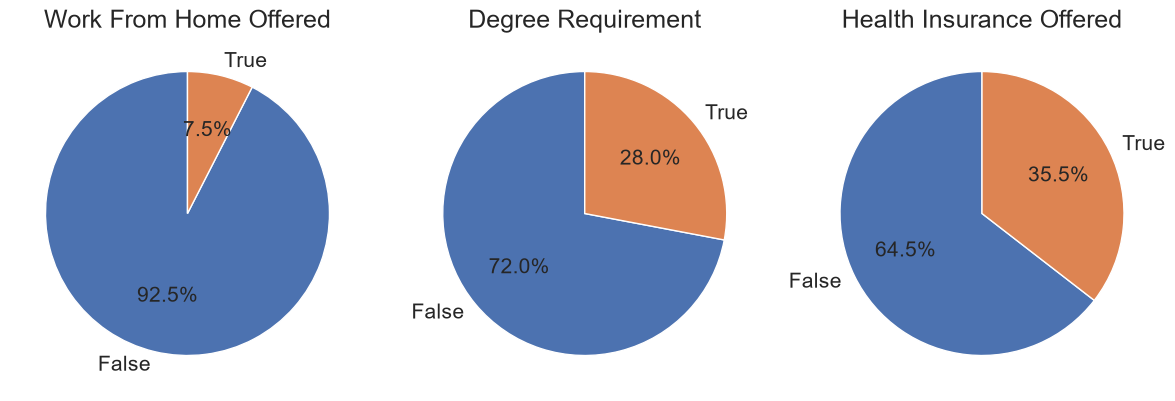

In [5]:
# Rewrite the above with a for loop

dict1 = {
'job_work_from_home':'Work From Home Offered',
'job_no_degree_mention':'Degree Requirement',
'job_health_insurance':'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (col, title) in enumerate(dict1.items()):
    df_DA_IN[col].value_counts().plot(kind='pie',autopct ='%.1f%%', ax=ax[i], title = title, startangle=90,   textprops={'fontsize': 15},)
    ax[i].set_title(title, size= 18)

plt.tight_layout()

### Companies to Explore:

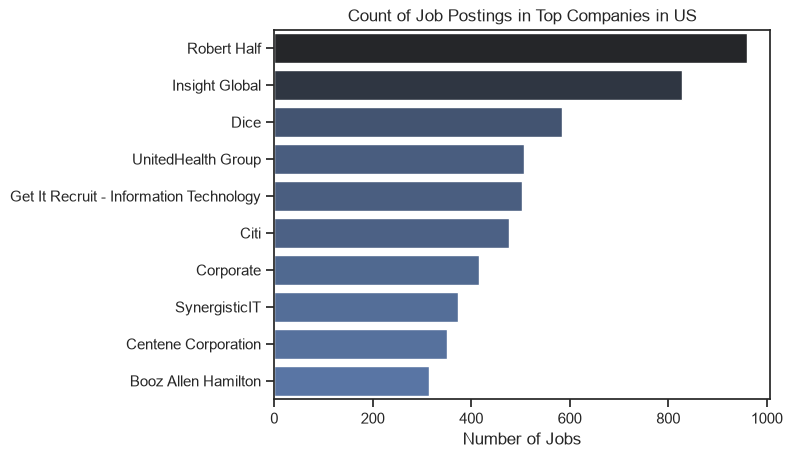

In [7]:
df_plot = df_DA_IN['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.title('Count of Job Postings in Top Companies in US')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()